# K-Means

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
from sklearn.metrics import silhouette_score, davies_bouldin_score
import plotly.express as px
from sklearn.preprocessing import RobustScaler
import warnings
warnings.filterwarnings('ignore')

## California Housing

### Paso 1: Carga del conjunto de datos

Queremos ser capaces de clasificar casas según su la región en la que se encuentren y del ingreso medio. Para ello, utilizaremos el famoso conjunto de datos California Housing. Se construyó utilizando los datos del censo de California de 1990. Contiene una fila por grupo de bloques censales. Un grupo de bloques es la unidad geográfica más pequeña para la que se publican datos del censo de USA.   
En este caso solo nos interesan las columnas `Latitude`, `Longitude` y `MedInc`.

In [3]:
df = pd.read_csv('../data/raw/housing.csv')
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
df.drop(['HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'MedHouseVal'], axis=1, inplace=True) 
df

,MedInc,Latitude,Longitude
0,8.3252,37.88,-122.23
1,8.3014,37.86,-122.22
2,7.2574,37.85,-122.24
3,5.6431,37.85,-122.25
4,3.8462,37.85,-122.25
...,...,...,...
20635,1.5603,39.48,-121.09
20636,2.5568,39.49,-121.21
20637,1.7000,39.43,-121.22
20638,1.8672,39.43,-121.32


In [5]:
df.shape

(20640, 3)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   MedInc     20640 non-null  float64
 1   Latitude   20640 non-null  float64
 2   Longitude  20640 non-null  float64
dtypes: float64(3)
memory usage: 483.9 KB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
Latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
Longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100


In [8]:
df.duplicated().sum()

np.int64(5)

In [9]:
# To show all the duplicated raws 
duplicated = df[df.duplicated(keep=False)]
duplicated

,MedInc,Latitude,Longitude
4569,2.3438,34.07,-118.27
4571,2.3438,34.07,-118.27
4605,15.0001,34.07,-118.33
4606,15.0001,34.07,-118.33
5291,15.0001,34.08,-118.42
8852,15.0001,34.08,-118.42
8853,15.0001,34.07,-118.41
8854,15.0001,34.07,-118.41
16328,4.3008,38.02,-121.33
16331,4.3008,38.02,-121.33


In [10]:
# To modify deleting duplicated ones and create a new copy of data frame
df.drop_duplicates(inplace=True)

In [11]:
df.shape

(20635, 3)

In [12]:
df.isnull().sum()

MedInc       0
Latitude     0
Longitude    0
dtype: int64

In [13]:
df[(df == 0).any(axis=1)]

,MedInc,Latitude,Longitude


#### Escalado - RobustScaler()

In [14]:
robust_scaler = RobustScaler()

df_scaled = robust_scaler.fit_transform(df)
df_scaled = pd.DataFrame(df_scaled,
                         columns=df.columns)

df_scaled

,MedInc,Latitude,Longitude
0,2.197981,0.957672,-0.986807
1,2.187061,0.952381,-0.984169
2,1.708052,0.949735,-0.989446
3,0.967378,0.949735,-0.992084
4,0.142923,0.949735,-0.992084
...,...,...,...
20630,-0.905896,1.380952,-0.686016
20631,-0.448681,1.383598,-0.717678
20632,-0.841799,1.367725,-0.720317
20633,-0.765084,1.367725,-0.746702


#### El gráfico 3D

In [15]:
fig = px.scatter_3d(df_scaled,
                    x='Latitude',
                    y='Longitude',
                    z='MedInc',
                    color='MedInc',
                    width=1000,
                    height=500,
                    color_discrete_sequence=["#E58139", "#39E581", "#8139E5"])
camera = dict(up=dict(x=1, y=3.5, z=0),
              eye=dict(x=2, y=0, z=0))

fig.update_layout(scene_camera=camera)
fig.show()

#### Elbow

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

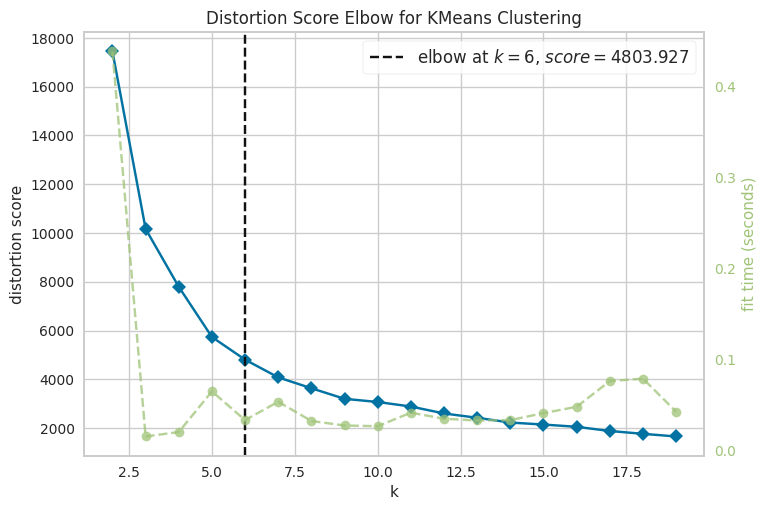

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [16]:
elbow_vis = KElbowVisualizer(KMeans(random_state=18), k=(2, 20))
elbow_vis.fit(df_scaled)
elbow_vis.show()

### Paso 2: Construye un K-Means

In [17]:
model = KMeans(n_clusters=6,
               random_state=18)
df_scaled['cluster'] = model.fit_predict(df_scaled)
df_scaled

,MedInc,Latitude,Longitude,cluster
0,2.197981,0.957672,-0.986807,1
1,2.187061,0.952381,-0.984169,1
2,1.708052,0.949735,-0.989446,1
3,0.967378,0.949735,-0.992084,1
4,0.142923,0.949735,-0.992084,5
...,...,...,...,...
20630,-0.905896,1.380952,-0.686016,5
20631,-0.448681,1.383598,-0.717678,5
20632,-0.841799,1.367725,-0.720317,5
20633,-0.765084,1.367725,-0.746702,5


In [18]:
df_scaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20635 entries, 0 to 20634
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   MedInc     20635 non-null  float64
 1   Latitude   20635 non-null  float64
 2   Longitude  20635 non-null  float64
 3   cluster    20635 non-null  int32  
dtypes: float64(3), int32(1)
memory usage: 564.4 KB


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

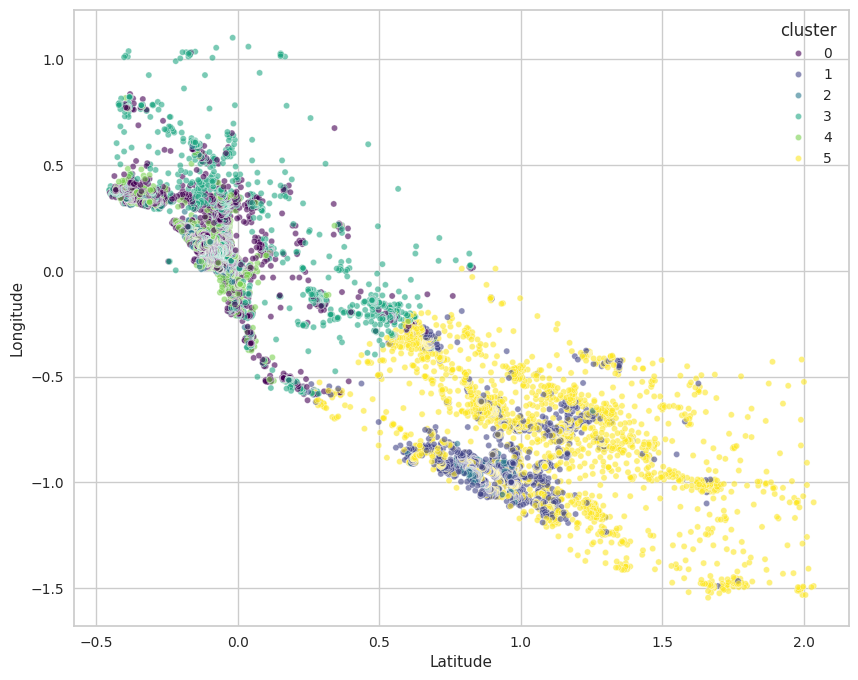

In [19]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=df_scaled, x='Latitude', y='Longitude', hue='cluster', palette='viridis', alpha=0.6, s=20)
plt.show()

Text(0.5, 0, 'Cluster')

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

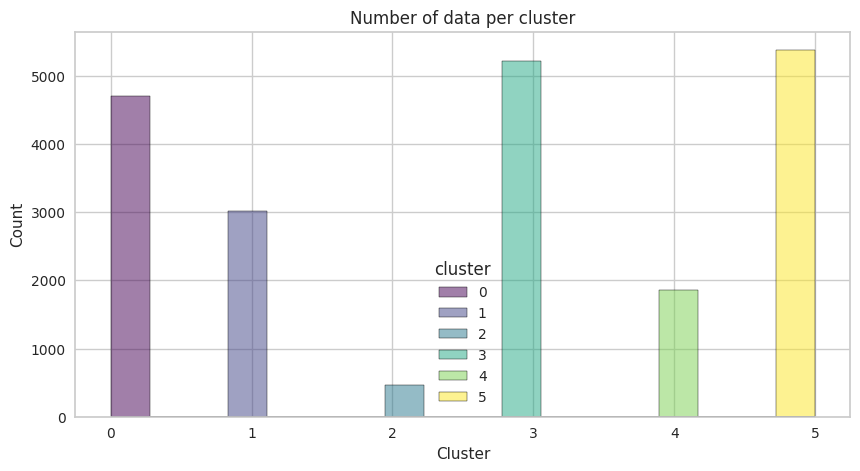

In [20]:
plt.figure(figsize=(10,5))
sns.histplot(data=df_scaled, x='cluster', hue='cluster', palette='viridis')
plt.title('Number of data per cluster')
plt.xlabel('Cluster')

In [21]:
df_scaled['cluster'].value_counts()

cluster
5    5378
3    5213
0    4705
1    3014
4    1863
2     462
Name: count, dtype: int64

> Observaciones:
>
> - Los clusters 5, 3 y 0 representan la mayor parte de las viviendas del conjunto de datos.
> - El cluster 2 es claramente el más pequeño (apenas 462 observaciones).

In [22]:
df_scaled['cluster'].value_counts().sort_values(ascending=False)

cluster
5    5378
3    5213
0    4705
1    3014
4    1863
2     462
Name: count, dtype: int64

In [23]:
df_scaled.groupby('cluster').mean()

,MedInc,Latitude,Longitude
cluster,,,
0,0.298685,-0.092066,0.125171
1,0.810605,0.917883,-0.904033
2,3.389114,0.333826,-0.371204
3,-0.529903,-0.059388,0.127053
4,1.354829,-0.103389,0.115309
5,-0.373712,1.023550,-0.827295


In [24]:
fig = px.scatter_3d(df_scaled,
                    x='Latitude',
                    y='Longitude',
                    z='MedInc',
                    color='cluster',
                    width=900,
                    height=600)
fig.show()

> Observaciones:
> - **Cluster 0**: tiene un ingreso ligeramente por encima de la mediana de todo el dataset.
> - **Cluster 1**: ingreso más alto que la mediana.
> - **Cluster 2**: ingresos muy altos.
> - **Cluster 3**: ingresos bajos.
> - **Cluster 4**: ingresos medios-altos.
> - **Cluster 5**: ingresos bajos.   
>
> Estamos viendo que a los clusters podríamos asignarles nombres según el nivel de ingreso, para distinguirlos mejor.

In [25]:
df_scaled['cluster'] = df_scaled['cluster'].astype('category')

In [27]:
# Labels per income
cluster_labels = {0: 'Medium',
                  1: 'Medium - high',
                  2: 'Very high',
                  3: 'Low',
                  4: 'High',
                  5: 'Low - medium'}

In [28]:
df_scaled['income_level'] = df_scaled['cluster'].map(cluster_labels)

In [29]:
df_scaled

,MedInc,Latitude,Longitude,cluster,income_level
0,2.197981,0.957672,-0.986807,1,Medium - high
1,2.187061,0.952381,-0.984169,1,Medium - high
2,1.708052,0.949735,-0.989446,1,Medium - high
3,0.967378,0.949735,-0.992084,1,Medium - high
4,0.142923,0.949735,-0.992084,5,Low - medium
...,...,...,...,...,...
20630,-0.905896,1.380952,-0.686016,5,Low - medium
20631,-0.448681,1.383598,-0.717678,5,Low - medium
20632,-0.841799,1.367725,-0.720317,5,Low - medium
20633,-0.765084,1.367725,-0.746702,5,Low - medium


> Observaciones:
>
> 